# 09b — Spectral resolution + sigma-clip diagnostics

Two questions paired in one notebook because they both turn on whether
the **best-fit ppxf model is accurately matching the per-pixel depth of
the strong absorption features** in the deflector spectrum.

1. **LSF chain.** ppxf needs the LSF mismatch
   `Δσ²(λ) = σ²_template(λ) − σ²_galaxy(λ)` to convolve templates to
   match the data. We pass `fwhm_gal_dict` (a wavelength-resolved galaxy
   FWHM) into `lib.sps_lib`. This notebook **verifies the chain works
   end-to-end** — that the input galaxy FWHM matches what KCWI actually
   delivers, that the templates' native FWHM is what the ppxf .npz files
   advertise, and that ppxf's broadening step closes the gap correctly
   over the rest-frame fit window.

2. **Outlier rejection.** ppxf can do iterative κ–σ clipping (`clean=True`)
   and we can also manually grow the rejected-pixel mask by N pixels on
   either side of each outlier (a "buffer" — important when template
   imperfections produce a *correlated* residual across a few pixels
   rather than spike-and-recover). We compare:
   - baseline (current pipeline)
   - `clean=True`
   - manual buffer: ±3 pixels on each side of any |resid/noise|>3 pix
   - manual buffer: ±4 pixels

The overarching question is whether **our σ_e is being driven by template
mismatch in the line cores** — if expanding the mask around imperfect
fits drops σ significantly, that's a sign we're recovering σ_e from
features the templates don't model well.

## §0 — Imports and aperture-spectrum setup

In [1]:
import os, sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from scripts.final_sigma_e import (
    load_setup, extract_aperture_spectrum, Z_SYSTEMIC, BOOT_SEED, WINDOW,
)
from scripts.bootstrap_ppxf import (
    setup_ppxf_inputs_from_spectrum, C_KMS, SPS_NATIVE_FRAME,
)
from ppxf.ppxf import ppxf

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=12)

# Repo-root walk-up
REPO_ROOT = os.path.abspath(os.getcwd())
while REPO_ROOT != '/' and not os.path.exists(os.path.join(REPO_ROOT, 'CLAUDE.md')):
    REPO_ROOT = os.path.dirname(REPO_ROOT)
print(f"Repo root: {REPO_ROOT}")

# Load cube + R_e + arc mask
_cwd = os.getcwd()
os.chdir(REPO_ROOT)
try:
    state = load_setup()
finally:
    os.chdir(_cwd)
R_E = state['R_E']
print(f"\nR_e = {R_E:.3f}\"  (mean F140W+F200LP CoG)")

flux, noise, n_kept, sn_band = extract_aperture_spectrum(state, r_max=R_E, mask_weight=0.0)
n_med = float(np.nanmedian(noise[noise > 0]))
n_floor = n_med * 0.1
n_zero = int(np.sum(~(noise > 0)))
noise = np.where(noise > 0, noise, n_floor)
print(f"R<R_e aperture: {n_kept} active spaxels, S/N(6500-7500) = {sn_band:.1f}")
print(f"Noise floor applied to {n_zero} zero/negative pixels (median noise = {n_med:.4g})")

Repo root: /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry
──────────────────────────────────────────────────────────────────────
§1  Load IFU cube + HST images + arc masks
──────────────────────────────────────────────────────────────────────


  IFU cube      shape=(3317, 100, 100)  pix=0.300"/spax  λ=5625-8941 Å
  F140W+mask    pix=0.080"/pix  mask=1121 pix
  F200LP+mask   pix=0.050"/pix  mask=2512 pix (arc-tuned)

§2  HST-mean center via centroid_2dg on F140W + F200LP


  F140W centroid  (RA,Dec) = (31.55610, -1.23815)
  F200LP centroid (RA,Dec) = (31.55615, -1.23823)
  |Δcentroid| = 0.357"  (FAIL)
  HST-mean → IFU sub-pixel (50.147, 54.264)

§3  R_e from masked curve-of-growth (F140W + F200LP)
  R_e(F140W masked)  = 2.168"
  R_e(F200LP masked) = 2.441"
  R_e (headline mean) = 2.305"  = 16.23 kpc
  R_e(CaHK + G-band depth) = 2.866"  (+0.561" vs headline mean)

§4  r_spax map + reprojected F200LP arc mask
  arc_spax_mask: 69 of 10000 spaxels flagged (0.69%)

R_e = 2.305"  (mean F140W+F200LP CoG)
R<R_e aperture: 146 active spaxels, S/N(6500-7500) = 3.8
Noise floor applied to 2 zero/negative pixels (median noise = 0.003385)


## §1 — LSF chain end-to-end verification

ppxf needs to know two things to recover the *intrinsic* stellar LOSVD:
- the **galaxy** instrumental LSF as a function of λ (we pass this via
  `fwhm_gal_dict` into `lib.sps_lib`)
- the **template** native LSF (encoded in each `spectra_<sps>_9.0.npz`'s
  `fwhm` array)

The convolution step inside `lib.sps_lib` does
`Δσ_pix = sqrt(max(σ²_gal − σ²_temp, 0)) / velscale` (in log-λ pixels),
so when templates are *coarser* than the galaxy (FSPS/EMILES @ 80 km/s
vs KCWI @ 13 km/s) the templates **stay at their native resolution**.
The recovered σ then includes the unresolved difference.

We verify three things:
1. The KCWI galaxy FWHM passed in matches the cube's `DISPSCAL × dλ_pix`
   in observed λ.
2. The templates' native FWHM matches what the .npz files advertise.
3. The post-`lib.sps_lib` `sps.fwhm` is consistent with the galaxy LSF
   in the regime where templates are *finer* than the galaxy (XSL).

In [2]:
# Compute KCWI σ_inst(λ) from the cube header used in nb09a.
hdr = state['hdr']
crval = hdr['CRVAL3']; cdelt = hdr['CD3_3']; crpix = hdr['CRPIX3']
n_lam = hdr['NAXIS3']
pix = np.arange(n_lam)
lam_obs = crval + cdelt * (pix + 1 - crpix)
wdisp = float(hdr['DISPSCAL'])
dlam_obs = np.gradient(lam_obs)
fwhm_obs = 2.355 * wdisp * dlam_obs
sig_inst_obs = fwhm_obs / 2.355 / lam_obs * 299792.458   # km/s vs obs λ
print(f"KCWI cube  obs λ = [{lam_obs[0]:.0f},{lam_obs[-1]:.0f}]  "
      f"DISPSCAL = {wdisp:.3f}  dλ_pix(obs) = {dlam_obs.mean():.3f} Å")
print(f"  → galaxy FWHM_obs = {fwhm_obs.mean():.3f} Å (≈ {sig_inst_obs.mean():.1f} km/s)")

# Headline window: rest 3879-4476 Å → obs 6500-7500 Å.
lam_obs_range = (6500.0, 7500.0)
mask = (lam_obs >= lam_obs_range[0]) & (lam_obs <= lam_obs_range[1])
lam_rest = lam_obs[mask] / (1 + Z_SYSTEMIC)
fwhm_rest = fwhm_obs[mask] / (1 + Z_SYSTEMIC)
sig_inst_rest = sig_inst_obs[mask]
print(f"  In rest 3879-4476 Å:  FWHM_rest median = {np.median(fwhm_rest):.3f} Å, "
      f"σ_inst = {np.median(sig_inst_rest):.2f} km/s, R = {np.median(lam_rest/fwhm_rest):.0f}")

KCWI cube  obs λ = [5625,8941]  DISPSCAL = 0.294  dλ_pix(obs) = 1.000 Å
  → galaxy FWHM_obs = 0.692 Å (≈ 12.3 km/s)
  In rest 3879-4476 Å:  FWHM_rest median = 0.413 Å, σ_inst = 12.59 km/s, R = 10110


Saved → /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09b_lsf_chain.png


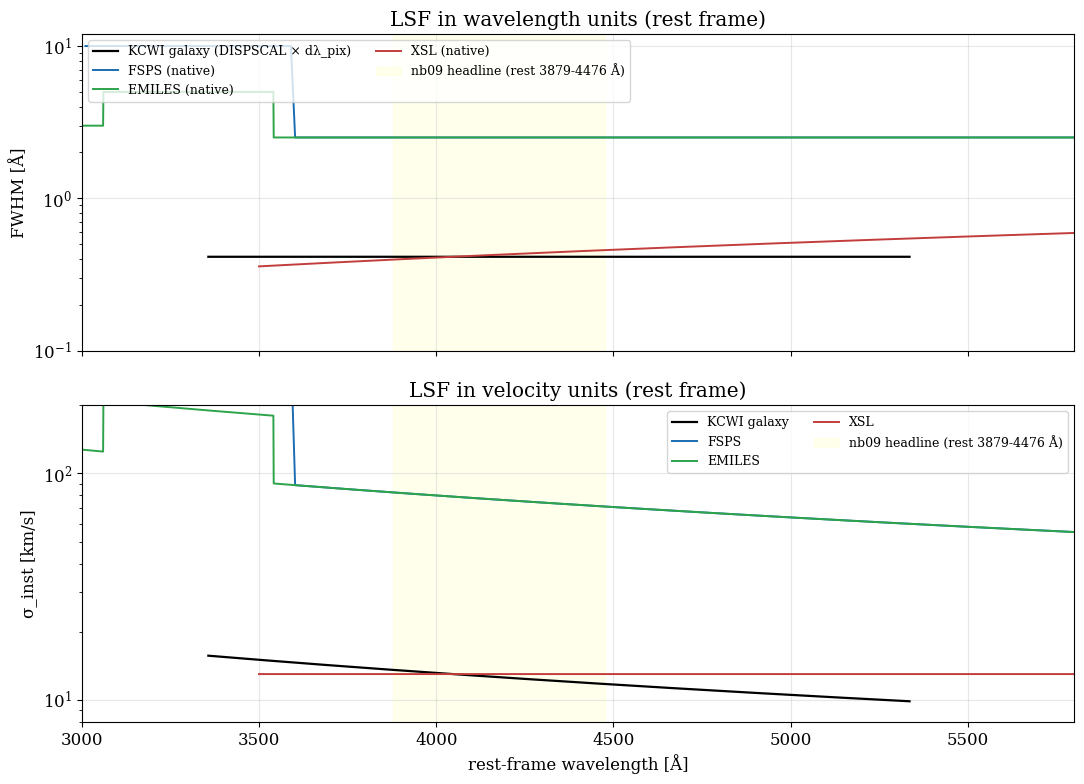

In [3]:
# Probe the three SPS template .npz files — directly read their native LSF.
from importlib import resources
ppxf_dir = resources.files('ppxf')
sps_meta = {}
for sps in ('fsps', 'emiles', 'xsl'):
    f = ppxf_dir / 'sps_models' / f'spectra_{sps}_9.0.npz'
    d = np.load(f, allow_pickle=True)
    sps_meta[sps] = dict(lam=d['lam'].astype(float), fwhm=d['fwhm'].astype(float))

# Plot in rest-frame, restricted to ~3000-5500 Å (covers all our windows)
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ax_fwhm, ax_sigma = axes
clr = {'fsps':'#1b6cb0', 'emiles':'#2da34a', 'xsl':'#c33d3d', 'kcwi':'k'}

# Galaxy in rest frame, full cube extent
lam_full_rest = lam_obs / (1 + Z_SYSTEMIC)
fwhm_full_rest = fwhm_obs / (1 + Z_SYSTEMIC)
sig_full_rest = sig_inst_obs                    # σ_inst in km/s is z-invariant
ax_fwhm.plot(lam_full_rest, fwhm_full_rest, lw=1.6, color=clr['kcwi'],
             label='KCWI galaxy (DISPSCAL × dλ_pix)')
ax_sigma.plot(lam_full_rest, sig_full_rest, lw=1.6, color=clr['kcwi'],
              label='KCWI galaxy')

# SPS templates
for sps in ('fsps', 'emiles', 'xsl'):
    L = sps_meta[sps]['lam']; F = sps_meta[sps]['fwhm']
    sigma_sps = F / 2.355 / L * 299792.458
    keep = (L >= 3000) & (L <= 5800)
    ax_fwhm.plot(L[keep], F[keep], lw=1.4, color=clr[sps], label=f'{sps.upper()} (native)')
    ax_sigma.plot(L[keep], sigma_sps[keep], lw=1.4, color=clr[sps], label=f'{sps.upper()}')

# Mark the headline rest window
for ax in axes:
    ax.axvspan(3879, 4476, color='lightyellow', alpha=0.6, zorder=0,
               label='nb09 headline (rest 3879-4476 Å)')

ax_fwhm.set_ylabel('FWHM [Å]')
ax_fwhm.set_yscale('log')
ax_fwhm.set_ylim(0.1, 12)
ax_fwhm.legend(fontsize=9, ncol=2, loc='upper left')
ax_fwhm.grid(alpha=0.3)
ax_fwhm.set_title("LSF in wavelength units (rest frame)")

ax_sigma.set_ylabel('σ_inst [km/s]')
ax_sigma.set_yscale('log')
ax_sigma.set_ylim(8, 200)
ax_sigma.set_xlabel('rest-frame wavelength [Å]')
ax_sigma.set_xlim(3000, 5800)
ax_sigma.legend(fontsize=9, ncol=2, loc='upper right')
ax_sigma.grid(alpha=0.3)
ax_sigma.set_title("LSF in velocity units (rest frame)")

plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09b_lsf_chain.png')
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
fig.savefig(fig_path, dpi=140)
print(f"Saved → {fig_path}")
plt.show()

In [4]:
# Verify: when ppxf's lib.sps_lib gets fwhm_gal_dict, does sps.fwhm match
# the galaxy LSF (in rest-frame Å) after broadening?
inputs_test = setup_ppxf_inputs_from_spectrum(
    flux, noise, hdr, sps_name='xsl', z=Z_SYSTEMIC,
    lam_obs_range=lam_obs_range, lam_fit_range=lam_obs_range,
    lam_range_temp=(3500.0, 5500.0),
    verbose=True, frame_galaxy='auto',
)
sps = inputs_test['sps']
lam_temp = inputs_test['lam_temp']
print(f"\nXSL sps post-lib.sps_lib:")
print(f"  templates shape: {sps.templates.shape}")
print(f"  lam_temp range: [{lam_temp[0]:.1f}, {lam_temp[-1]:.1f}] Å (rest)")
# sps.fwhm exists if lib.sps_lib bound it — show what we have
for attr in ('fwhm', 'fwhm_gal', 'fwhm_temp'):
    if hasattr(sps, attr):
        v = getattr(sps, attr)
        if hasattr(v, 'shape'):
            print(f"  sps.{attr}: shape={v.shape}, range=[{np.min(v):.3f},{np.max(v):.3f}] Å")
        else:
            print(f"  sps.{attr}: {v}")

# Does the fitting routine actually see the galaxy FWHM dict?
gal_fwhm_at_4000 = float(np.interp(4000.0, lam_full_rest, fwhm_full_rest))
xsl_fwhm_at_4000 = float(np.interp(4000.0, sps_meta['xsl']['lam'], sps_meta['xsl']['fwhm']))
print(f"\n@ rest 4000 Å:")
print(f"  Galaxy FWHM_rest = {gal_fwhm_at_4000:.3f} Å (σ = {gal_fwhm_at_4000/2.355/4000*C_KMS:.2f} km/s)")
print(f"  XSL    FWHM_native = {xsl_fwhm_at_4000:.3f} Å (σ = {xsl_fwhm_at_4000/2.355/4000*C_KMS:.2f} km/s)")
diff_kms = np.sqrt(max((gal_fwhm_at_4000/2.355)**2 - (xsl_fwhm_at_4000/2.355)**2, 0)) / 4000 * C_KMS
print(f"  Δσ (broaden XSL → galaxy): {diff_kms:.2f} km/s")

Setting up ppxf inputs for xsl from user-supplied spectrum...


  Templates: xsl (8 templates)
  Galaxy: 1000 pixels, Good pixels: 926
  Velscale: 42.90 km/s/pix

XSL sps post-lib.sps_lib:
  templates shape: (3159, 26, 8)
  lam_temp range: [3500.2, 5499.9] Å (rest)

@ rest 4000 Å:
  Galaxy FWHM_rest = 0.413 Å (σ = 13.15 km/s)
  XSL    FWHM_native = 0.408 Å (σ = 13.00 km/s)
  Δσ (broaden XSL → galaxy): 1.99 km/s


## §2 — Absorption-line depth diagnostic

For the headline window we run a single ppxf fit at degree=21 (median of
[15,29]) for each SPS, then measure the **per-line-core depth** at each
strong absorption feature and compare galaxy vs best-fit. A
template-imperfection signature is when the model line core is
systematically *shallower* (or deeper) than the data — that flux is what
the LOSVD would otherwise have to absorb by broadening.

In [5]:
# Strong stellar absorption lines in the rest 3800-5000 Å region
ABS_LINES = [
    ('Ca K',     3933.66, 4),
    ('Ca H+Hε', 3968.50, 4),
    ('Hδ',       4101.74, 4),
    ('Fe 4045',  4045.81, 3),
    ('Sr II',    4077.71, 3),
    ('CN 4216',  4216.0,  4),
    ('G-band',   4304.40, 4),
    ('Hγ',       4340.47, 4),
    ('Fe 4383',  4383.55, 3),
]

def line_core_depth(lam, flux_arr, line_lam, half_window_pix, continuum_window=12):
    # Depth = (continuum - core_min) / continuum
    # Continuum: median in ±continuum_window pix EXCLUDING core ±half_window_pix
    i = int(np.argmin(np.abs(lam - line_lam)))
    lo = max(0, i - continuum_window); hi = min(len(lam), i + continuum_window + 1)
    core_lo = max(0, i - half_window_pix); core_hi = min(len(lam), i + half_window_pix + 1)
    cont_pix = list(range(lo, core_lo)) + list(range(core_hi, hi))
    if not cont_pix:
        return np.nan, np.nan, np.nan
    cont = float(np.median(flux_arr[cont_pix]))
    core = float(np.min(flux_arr[core_lo:core_hi]))
    depth = (cont - core) / cont if cont > 0 else np.nan
    return cont, core, depth

# Run a single fit per SPS at degree=21
deg = 21
fits = {}
for sps in ('fsps', 'emiles', 'xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_range, lam_fit_range=lam_obs_range,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 5500.0),
        verbose=False, frame_galaxy='auto',
    )
    pp = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
              inp['velscale'], inp['start'], goodpixels=inp['goodpixels'],
              plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
              lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
    fits[sps] = dict(inp=inp, pp=pp, lam_rest=inp['lam_gal_rest'],
                     galaxy=inp['galaxy'], bestfit=pp.bestfit,
                     V=pp.sol[0], sig=pp.sol[1], chi2=pp.chi2)
    print(f"  {sps}: σ = {pp.sol[1]:.1f} km/s, V = {pp.sol[0]:+.1f} km/s, χ²/DOF = {pp.chi2:.4f}")

# Report per-line depth for each fit
print()
print(f"{'Line':<10}{'λ_rest':>9}", end='')
for sps in ('fsps', 'emiles', 'xsl'):
    print(f"{sps + ' gal/fit':>16}{sps + ' depth ratio':>17}", end='')
print()
print('-' * 110)
depth_table = {sps: {} for sps in fits}
for name, lwl, hw in ABS_LINES:
    row = f"{name:<10}{lwl:>9.2f}"
    for sps, f in fits.items():
        cg, _, dg = line_core_depth(f['lam_rest'], f['galaxy'], lwl, hw)
        cf, _, df = line_core_depth(f['lam_rest'], f['bestfit'], lwl, hw)
        ratio = df / dg if dg and dg > 0 else np.nan
        depth_table[sps][name] = dict(d_gal=dg, d_fit=df, ratio=ratio)
        row += f"  d_gal={dg:5.3f} d_fit={df:5.3f}  ratio={ratio:5.3f}"
    print(row)

/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: divide by zero encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: overflow encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: invalid value encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: divide by zero encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: overflow encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/env

  fsps: σ = 262.5 km/s, V = -15.8 km/s, χ²/DOF = 0.0488
  emiles: σ = 276.1 km/s, V = -7.3 km/s, χ²/DOF = 0.0491


  xsl: σ = 284.5 km/s, V = -3.9 km/s, χ²/DOF = 0.0491

Line         λ_rest    fsps gal/fit fsps depth ratio  emiles gal/fitemiles depth ratio     xsl gal/fit  xsl depth ratio
--------------------------------------------------------------------------------------------------------------
Ca K        3933.66  d_gal=0.260 d_fit=0.113  ratio=0.435  d_gal=0.260 d_fit=0.129  ratio=0.497  d_gal=0.260 d_fit=0.122  ratio=0.468
Ca H+Hε     3968.50  d_gal=0.264 d_fit=0.143  ratio=0.540  d_gal=0.279 d_fit=0.146  ratio=0.525  d_gal=0.279 d_fit=0.147  ratio=0.526
Hδ          4101.74  d_gal=0.283 d_fit=0.054  ratio=0.191  d_gal=0.280 d_fit=0.065  ratio=0.233  d_gal=0.280 d_fit=0.065  ratio=0.234
Fe 4045     4045.81  d_gal=0.113 d_fit=0.029  ratio=0.259  d_gal=0.113 d_fit=0.026  ratio=0.233  d_gal=0.113 d_fit=0.029  ratio=0.260
Sr II       4077.71  d_gal=0.228 d_fit=0.021  ratio=0.093  d_gal=0.232 d_fit=0.016  ratio=0.067  d_gal=0.232 d_fit=0.016  ratio=0.069
CN 4216     4216.00  d_gal=0.062 d_fit=-0.00

Saved → /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09b_line_depth_per_sps.png


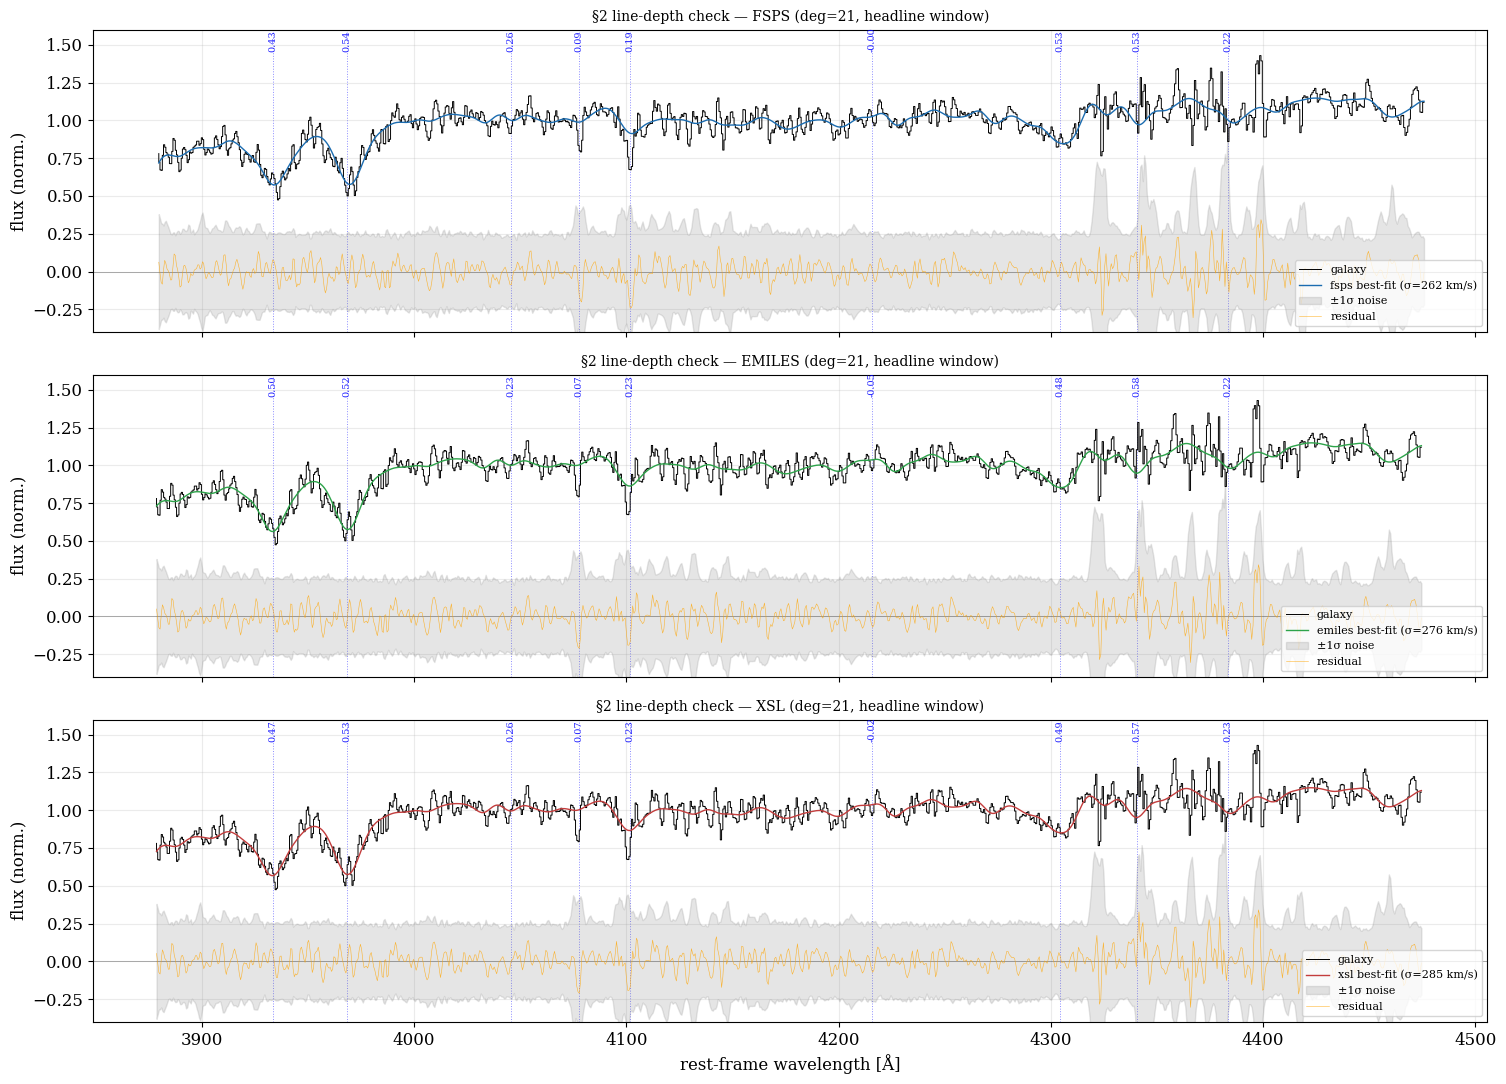

In [6]:
# Visual: galaxy + best-fit overlay, residuals near 0, line markers, depth-ratio annotation
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
clr = {'fsps':'#1b6cb0', 'emiles':'#2da34a', 'xsl':'#c33d3d'}
for ax, sps in zip(axes, ('fsps', 'emiles', 'xsl')):
    f = fits[sps]
    ax.step(f['lam_rest'], f['galaxy'], color='k', lw=0.7, label='galaxy', zorder=3)
    ax.plot(f['lam_rest'], f['bestfit'], color=clr[sps], lw=1.0,
            label=f"{sps} best-fit (σ={f['sig']:.0f} km/s)", zorder=4)
    resid = f['galaxy'] - f['bestfit']
    n = f['inp']['noise']
    ax.fill_between(f['lam_rest'], -n, +n, color='gray', alpha=0.20, zorder=2,
                    label='±1σ noise')
    ax.plot(f['lam_rest'], resid, color='orange', lw=0.4, alpha=0.8,
            label='residual', zorder=5)
    ax.axhline(0, color='k', lw=0.4, alpha=0.5)
    for name, lwl, _ in ABS_LINES:
        ax.axvline(lwl, color='blue', ls=':', lw=0.7, alpha=0.45, zorder=1)
        rat = depth_table[sps][name]['ratio']
        # Annotate ratio if data has a clean line
        if depth_table[sps][name]['d_gal'] and depth_table[sps][name]['d_gal'] > 0.02:
            ax.text(lwl, 1.45, f"{rat:.2f}", fontsize=7, color='blue',
                    ha='center', va='bottom', alpha=0.85, rotation=90)
    ax.set_ylabel('flux (norm.)')
    ax.set_ylim(-0.4, 1.6)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_title(f"§2 line-depth check — {sps.upper()} (deg={deg}, headline window)",
                 fontsize=10)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('rest-frame wavelength [Å]')
plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09b_line_depth_per_sps.png')
fig.savefig(fig_path, dpi=140)
print(f"Saved → {fig_path}")
plt.show()

## §3 — ppxf `clean=True` (κ=3 iterative outlier rejection)

ppxf's `clean=True` does iterative κ=3 σ-clipping of the residuals,
removing outlier pixels from `goodpixels` and re-fitting until
convergence. Outlier pixels are typically: cosmics that survived the
sky reduction; emission residuals at gas lines; template imperfections
where neither FSPS nor EMILES nor XSL captures the right stellar mix.

Compare baseline vs `clean=True` σ recovery per SPS.

In [7]:
fits_clean = {}
print(f"{'SPS':<8}{'baseline σ':>14}{'clean=True σ':>16}{'Δσ':>8}{'n_pix dropped':>16}")
print('-' * 70)
for sps in ('fsps', 'emiles', 'xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_range, lam_fit_range=lam_obs_range,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 5500.0),
        verbose=False, frame_galaxy='auto',
    )
    pp = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
              inp['velscale'], inp['start'], goodpixels=inp['goodpixels'],
              plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
              lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True,
              clean=True)
    n_dropped = len(inp['goodpixels']) - len(pp.goodpixels)
    fits_clean[sps] = dict(pp=pp, lam_rest=inp['lam_gal_rest'],
                           galaxy=inp['galaxy'], bestfit=pp.bestfit,
                           goodpixels=pp.goodpixels,
                           V=pp.sol[0], sig=pp.sol[1], chi2=pp.chi2)
    base_sig = fits[sps]['sig']
    print(f"{sps:<8}{base_sig:>13.1f}  {pp.sol[1]:>14.1f}  {pp.sol[1]-base_sig:>+7.1f}  {n_dropped:>16d}")

SPS         baseline σ    clean=True σ      Δσ   n_pix dropped
----------------------------------------------------------------------


fsps            262.5           262.5     +0.0                 0
emiles          276.1           276.1     +0.0                 0


xsl             284.5           284.5     +0.0                 0


## §4 — Edge-buffer goodpixels (±3 / ±4 px around |resid/noise|>3 outliers)

`clean=True` rejects only the spike pixels themselves. Real template
mismatch produces *correlated* residuals that span 3–6 pixels. Manually
grow the rejected mask by N pixels on each side of any pixel with
`|residual / noise| > 3`, then re-fit.

In [8]:
def grow_mask(bad_idx, n_pix_total, buffer):
    # Bad pixel indices dilated by ±buffer pixels on each side
    bad = np.zeros(n_pix_total, dtype=bool)
    bad[bad_idx] = True
    # Dilate by `buffer`
    grown = bad.copy()
    for k in range(1, buffer + 1):
        grown[:-k] |= bad[k:]
        grown[k:]  |= bad[:-k]
    return grown

fits_buf = {sps: {} for sps in ('fsps', 'emiles', 'xsl')}
print(f"{'SPS':<8}{'buffer':>8}{'σ':>10}{'Δσ vs base':>14}{'n_pix kept':>14}")
print('-' * 60)
for sps in ('fsps', 'emiles', 'xsl'):
    base_sig = fits[sps]['sig']
    for buffer in (0, 3, 4, 5):
        # Reload setup to refresh goodpixels (since we'll modify them)
        inp = setup_ppxf_inputs_from_spectrum(
            flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
            lam_obs_range=lam_obs_range, lam_fit_range=lam_obs_range,
            lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 5500.0),
            verbose=False, frame_galaxy='auto',
        )
        # Identify outliers from baseline fit
        f_base = fits[sps]
        resid = f_base['galaxy'] - f_base['bestfit']
        n_arr = inp['noise']
        snr_resid = np.abs(resid / n_arr)
        outlier_idx = np.where(snr_resid > 3.0)[0]
        # Grow by `buffer` pixels
        if buffer == 0:
            keep = inp['goodpixels']
        else:
            grown_bad = grow_mask(outlier_idx, len(resid), buffer)
            full_bad = np.ones(len(resid), dtype=bool)
            full_bad[inp['goodpixels']] = False
            full_bad |= grown_bad
            keep = np.where(~full_bad)[0]
        pp = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                  inp['velscale'], inp['start'], goodpixels=keep,
                  plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
                  lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
        fits_buf[sps][buffer] = dict(pp=pp, sig=pp.sol[1], V=pp.sol[0],
                                     n_keep=len(keep), n_dropped=len(inp['goodpixels'])-len(keep))
        d_sig = pp.sol[1] - base_sig
        print(f"{sps:<8}{buffer:>8d}{pp.sol[1]:>10.1f}{d_sig:>+14.2f}{len(keep):>14d}")

SPS       buffer         σ    Δσ vs base    n_pix kept
------------------------------------------------------------


fsps           0     262.5         +0.00           926


fsps           3     262.5         +0.00           926


fsps           4     262.5         +0.00           926


fsps           5     262.5         +0.00           926


...

emiles         5     276.1         +0.00           926


xsl            0     284.5         +0.00           926


xsl            3     284.5         +0.00           926


xsl            4     284.5         +0.00           926


xsl            5     284.5         +0.00           926


## §5 — σ_e summary across all variants

SPS           baseline    clean=True      buffer=3      buffer=4      buffer=5
--------------------------------------------------------------------------------------------------------------
fsps             262.5         262.5         262.5         262.5         262.5
emiles           276.1         276.1         276.1         276.1         276.1
xsl              284.5         284.5         284.5         284.5         284.5
--------------------------------------------------------------------------------------------------------------
(σ_e values are single-degree, original-spectrum fits, not bootstrap-pooled.)
(headline reference: σ_e(<R_e) all3 pool N=500 = 268 ± 32 km/s)
Saved → /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09b_sigma_clip_summary.png


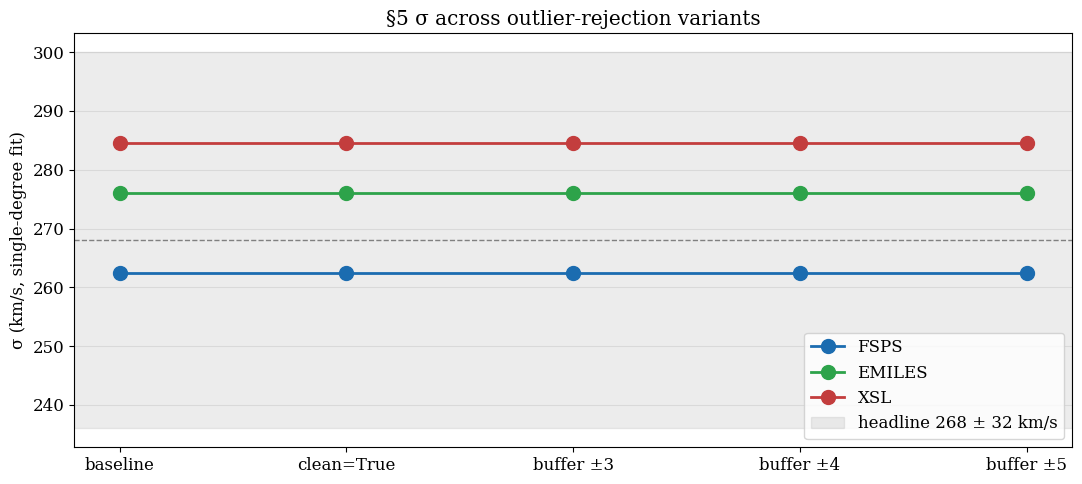

In [9]:
# One table comparing baseline / clean=True / buffer=3 / buffer=4 / buffer=5 per SPS
print("="*110)
print(f"{'SPS':<8}{'baseline':>14}{'clean=True':>14}{'buffer=3':>14}{'buffer=4':>14}{'buffer=5':>14}")
print('-'*110)
for sps in ('fsps', 'emiles', 'xsl'):
    base = fits[sps]['sig']
    cln  = fits_clean[sps]['sig']
    b3   = fits_buf[sps][3]['sig']
    b4   = fits_buf[sps][4]['sig']
    b5   = fits_buf[sps][5]['sig']
    def fmt(s):  return f"{s:6.1f}"
    print(f"{sps:<8}{fmt(base):>14}{fmt(cln):>14}{fmt(b3):>14}{fmt(b4):>14}{fmt(b5):>14}")
print('-'*110)
print("(σ_e values are single-degree, original-spectrum fits, not bootstrap-pooled.)")
print(f"(headline reference: σ_e(<R_e) all3 pool N=500 = 268 ± 32 km/s)")

# Plot comparison
fig, ax = plt.subplots(figsize=(11, 5))
xs = np.arange(5)
group_labels = ['baseline', 'clean=True', 'buffer ±3', 'buffer ±4', 'buffer ±5']
clr = {'fsps':'#1b6cb0', 'emiles':'#2da34a', 'xsl':'#c33d3d'}
for sps in ('fsps', 'emiles', 'xsl'):
    sigs = [fits[sps]['sig'], fits_clean[sps]['sig'],
            fits_buf[sps][3]['sig'], fits_buf[sps][4]['sig'], fits_buf[sps][5]['sig']]
    ax.plot(xs, sigs, marker='o', lw=2, ms=10, color=clr[sps], label=sps.upper())
ax.axhspan(268-32, 268+32, color='gray', alpha=0.15, label='headline 268 ± 32 km/s')
ax.axhline(268, color='gray', ls='--', lw=1)
ax.set_xticks(xs)
ax.set_xticklabels(group_labels)
ax.set_ylabel('σ (km/s, single-degree fit)')
ax.set_title("§5 σ across outlier-rejection variants")
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09b_sigma_clip_summary.png')
fig.savefig(fig_path, dpi=140)
print(f"Saved → {fig_path}")
plt.show()

## §6 — Can we actually model Hγ and Hβ as absorption?

ppxf's `util.determine_goodpixels(np.log(lam_gal_rest), lam_range_temp)`
**masks out Balmer lines + [OII] + [OIII] + Mg I + Na I as potential
emission contaminants by default**, with a default `width=800` km/s
window per line. So in our headline pipeline:

- **Hγ (4340 Å)** is masked over ±800 km/s → ±11.6 Å rest → ±~25 KCWI pix.
- **Hβ (4861 Å)** is masked over ±800 km/s → ±13.0 Å → ±~28 pix.
- This means our fit **does not use** the Balmer absorption depths. For
  a passive elliptical with no measurable gas emission, this is wasted
  signal: Hγ and Hβ absorption are 4-6% deep features that constrain
  the LOSVD width directly.

We re-fit with the Balmer lines **explicitly included** in `goodpixels`
(i.e., remove them from the bad-pixel list ppxf builds by default) and
compare the recovered σ + per-line depth ratios vs the masked baseline.

In [10]:
# Probe util.determine_goodpixels: which lines does it actually mask?
from ppxf import ppxf_util as util

lam_temp_range = (3000.0, 5500.0)
inp_probe = setup_ppxf_inputs_from_spectrum(
    flux, noise, hdr, sps_name='fsps', z=Z_SYSTEMIC,
    lam_obs_range=lam_obs_range, lam_fit_range=lam_obs_range,
    lam_range_temp=lam_temp_range, verbose=False, frame_galaxy='auto',
)
lam_rest = inp_probe['lam_gal_rest']
gp_default = inp_probe['goodpixels']
n_pix = len(lam_rest)
masked_default = np.ones(n_pix, dtype=bool); masked_default[gp_default] = False
print(f"Default goodpixels:  kept {len(gp_default)}/{n_pix},  masked {np.sum(masked_default)}")

# Find contiguous masked bands and label them by nearest known feature
def bands_from_bool(mask, lam):
    bands = []
    if not mask.any():
        return bands
    idx = np.where(mask)[0]
    start = prev = idx[0]
    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            bands.append((float(lam[start]), float(lam[prev])))
            start = prev = k
    bands.append((float(lam[start]), float(lam[prev])))
    return bands

LINE_CATALOG = {
    '[OII] 3727':  3727.10,
    'Hδ':          4101.74,
    'Hγ':          4340.47,
    'Hβ':          4861.33,
    '[OIII] 4959': 4958.91,
    '[OIII] 5007': 5006.84,
    'Mg I 5167':   5167.32,
    'Mg I 5172':   5172.68,
    'Mg I 5183':   5183.60,
    'Na I 5890':   5889.95,
    'Na I 5896':   5895.92,
    '[NI] 5200':   5200.0,
    '[SII] 6716':  6716.44,
    '[SII] 6731':  6730.81,
}
def closest_line(lo, hi):
    mid = 0.5 * (lo + hi)
    best = min(LINE_CATALOG.items(), key=lambda kv: abs(kv[1] - mid))
    return best[0], best[1]

print("\nDefault-masked bands (rest-frame):")
for lo, hi in bands_from_bool(masked_default, lam_rest):
    name, lwl = closest_line(lo, hi)
    span_kms = (hi - lo) / lwl * C_KMS
    print(f"  rest {lo:7.2f} – {hi:7.2f} Å  (Δ={hi-lo:5.2f} Å, {span_kms:6.0f} km/s)   ← {name} (λ={lwl:.2f})")
print("\nKey takeaway: any line in this list with name ≠ a gas/sky line is being")
print("dropped from the fit. For a passive ETG with no detected emission, that's")
print("wasted absorption signal — especially Hγ and Hβ.")

Default goodpixels:  kept 926/1000,  masked 74

Default-masked bands (rest-frame):
  rest 4091.21 – 4112.34 Å  (Δ=21.13 Å,   1544 km/s)   ← Hδ (λ=4101.74)
  rest 4329.12 – 4351.48 Å  (Δ=22.36 Å,   1544 km/s)   ← Hγ (λ=4340.47)

Key takeaway: any line in this list with name ≠ a gas/sky line is being
dropped from the fit. For a passive ETG with no detected emission, that's
wasted absorption signal — especially Hγ and Hβ.


In [11]:
# Re-fit with Balmer absorption lines explicitly INCLUDED.
# Strategy: take default bad-pixel set, then unmask the bands centered on
# Hδ / Hγ / Hβ (keep [OII], [OIII], Mg I, Na I masked since they could
# be emission for ETGs with weak gas).
BALMER = {'Hδ': 4101.74, 'Hγ': 4340.47, 'Hβ': 4861.33}
BALMER_HALF_WIDTH_PIX = 8   # ±8 pix to PRESERVE around Balmer cores when un-masking

def unmask_balmer(goodpixels_default, lam_rest, lines, half_width_pix):
    n = len(lam_rest)
    bad = np.ones(n, dtype=bool); bad[goodpixels_default] = False
    for nm, lwl in lines.items():
        if lwl < lam_rest[0] or lwl > lam_rest[-1]:
            continue
        i = int(np.argmin(np.abs(lam_rest - lwl)))
        lo = max(0, i - half_width_pix); hi = min(n, i + half_width_pix + 1)
        bad[lo:hi] = False
    return np.where(~bad)[0]

fits_balmer = {}
print(f"{'SPS':<8}{'baseline σ':>12}{'incl-Balmer σ':>16}{'Δσ':>8}"
      f"{'extra pix kept':>18}")
print('-' * 70)
for sps in ('fsps', 'emiles', 'xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_range, lam_fit_range=lam_obs_range,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 5500.0),
        verbose=False, frame_galaxy='auto',
    )
    gp_with_balmer = unmask_balmer(inp['goodpixels'], inp['lam_gal_rest'],
                                   BALMER, BALMER_HALF_WIDTH_PIX)
    pp = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
              inp['velscale'], inp['start'], goodpixels=gp_with_balmer,
              plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
              lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
    fits_balmer[sps] = dict(pp=pp, lam_rest=inp['lam_gal_rest'],
                            galaxy=inp['galaxy'], bestfit=pp.bestfit,
                            sig=pp.sol[1], V=pp.sol[0], chi2=pp.chi2,
                            goodpixels=gp_with_balmer)
    base_sig = fits[sps]['sig']
    extra = len(gp_with_balmer) - len(inp['goodpixels'])
    print(f"{sps:<8}{base_sig:>11.1f}  {pp.sol[1]:>15.1f}{pp.sol[1]-base_sig:>+8.2f}{extra:>18d}")

# Per-line depth ratios at Hγ + Hβ specifically
print("\nPer-Balmer-line depth ratios (galaxy/best-fit core depth):")
for sps in ('fsps', 'emiles', 'xsl'):
    f = fits_balmer[sps]
    print(f"  {sps}:")
    for nm, lwl in BALMER.items():
        if lwl < f['lam_rest'][0] or lwl > f['lam_rest'][-1]:
            continue
        cg, _, dg = line_core_depth(f['lam_rest'], f['galaxy'], lwl, 4)
        cf, _, df = line_core_depth(f['lam_rest'], f['bestfit'], lwl, 4)
        rat = df / dg if dg and dg > 0 else float('nan')
        print(f"    {nm:<6}  d_gal={dg:.3f}  d_fit={df:.3f}  ratio={rat:.3f}")

SPS       baseline σ   incl-Balmer σ      Δσ    extra pix kept
----------------------------------------------------------------------


/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: divide by zero encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: overflow encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: invalid value encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: divide by zero encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: overflow encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/env

fsps          262.5            263.5   +1.04                34
emiles        276.1            275.2   -0.95                34


xsl           284.5            286.7   +2.18                34

Per-Balmer-line depth ratios (galaxy/best-fit core depth):
  fsps:
    Hδ      d_gal=0.283  d_fit=0.056  ratio=0.198
    Hγ      d_gal=0.130  d_fit=0.062  ratio=0.475
  emiles:
    Hδ      d_gal=0.280  d_fit=0.060  ratio=0.213
    Hγ      d_gal=0.123  d_fit=0.061  ratio=0.499
  xsl:
    Hδ      d_gal=0.280  d_fit=0.058  ratio=0.207
    Hγ      d_gal=0.123  d_fit=0.059  ratio=0.477


Saved → /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09b_balmer_inclusion.png


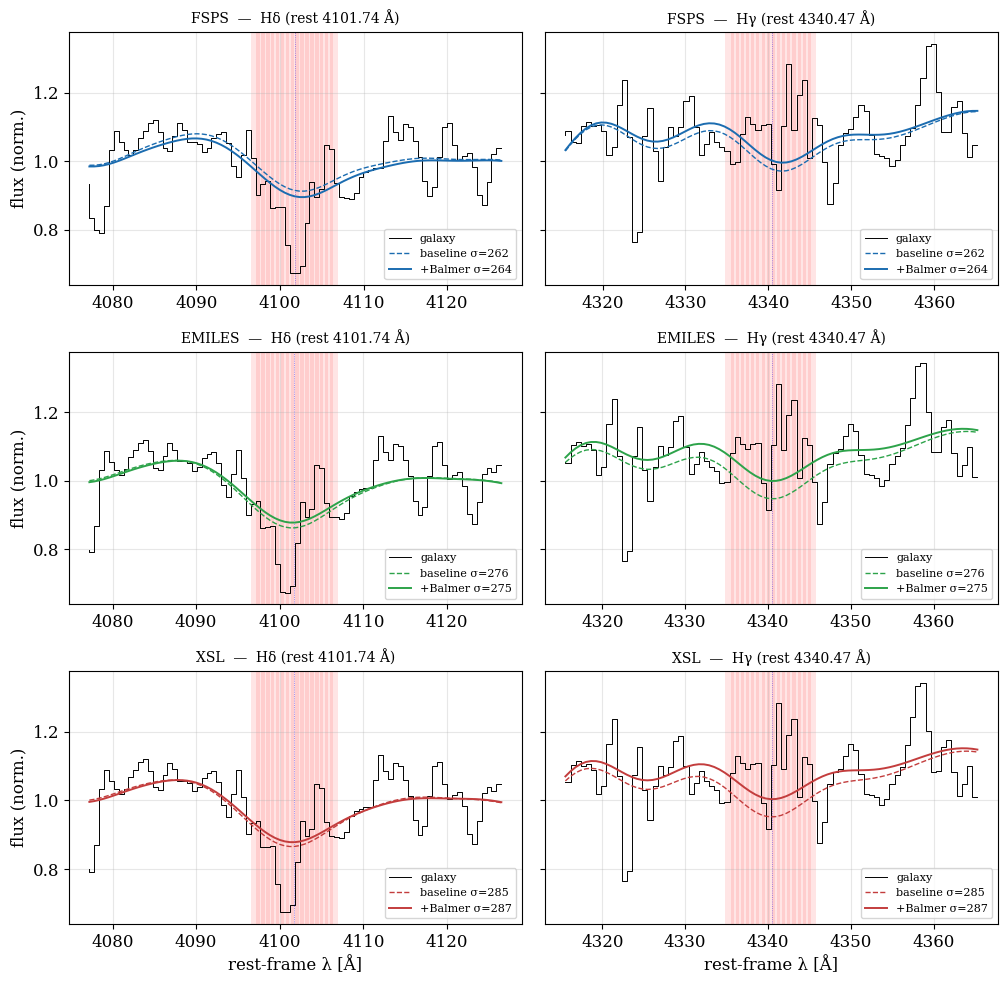

In [12]:
# Visual: zoom on Balmer regions, baseline (Balmer masked, dashed) vs
# Balmer-included (solid). Shaded red where pixels were excluded by
# baseline but included now.
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey='row')
clr = {'fsps':'#1b6cb0', 'emiles':'#2da34a', 'xsl':'#c33d3d'}
zoom_half = 25  # ±25 Å around each Balmer line

for irow, sps in enumerate(('fsps', 'emiles', 'xsl')):
    f_base = fits[sps]
    f_bal  = fits_balmer[sps]
    inp = f_base['inp']
    gp_default = inp['goodpixels']
    gp_balmer = f_bal['goodpixels']
    excluded_default = np.ones(len(f_base['lam_rest']), dtype=bool)
    excluded_default[gp_default] = False
    only_added = np.zeros_like(excluded_default); only_added[gp_balmer] = True
    only_added &= excluded_default
    for icol, (nm, lwl) in enumerate(BALMER.items()):
        ax = axes[irow, icol]
        if lwl < f_base['lam_rest'][0] or lwl > f_base['lam_rest'][-1]:
            ax.set_visible(False); continue
        m = (f_base['lam_rest'] >= lwl-zoom_half) & (f_base['lam_rest'] <= lwl+zoom_half)
        L = f_base['lam_rest'][m]; G = f_base['galaxy'][m]
        BFb = f_base['bestfit'][m]; BFi = f_bal['bestfit'][m]
        added = only_added[m]
        ax.step(L, G, color='k', lw=0.7, label='galaxy', zorder=3)
        ax.plot(L, BFb, color=clr[sps], lw=1.0, ls='--',
                label=f"baseline σ={f_base['sig']:.0f}", zorder=4)
        ax.plot(L, BFi, color=clr[sps], lw=1.4, ls='-',
                label=f"+Balmer σ={f_bal['sig']:.0f}", zorder=5)
        # Shade newly-added pixels
        for j, x in enumerate(L):
            if added[j]:
                ax.axvspan(x-0.5, x+0.5, color='red', alpha=0.10, lw=0)
        ax.axvline(lwl, color='blue', ls=':', lw=0.6, alpha=0.5)
        ax.set_title(f"{sps.upper()}  —  {nm} (rest {lwl:.2f} Å)", fontsize=10)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(alpha=0.3)
        if icol == 0:
            ax.set_ylabel('flux (norm.)')
        if irow == 2:
            ax.set_xlabel('rest-frame λ [Å]')
plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09b_balmer_inclusion.png')
fig.savefig(fig_path, dpi=140)
print(f"Saved → {fig_path}")
plt.show()

## §3.1 — Noise rescaling: rerun variants after fixing χ²/DOF ≈ 1

§2 found χ²/DOF ≈ 0.05 at every SPS in the headline window. That means
the noise vector we pass to ppxf is overestimated by sqrt(1/0.05) ≈ 4.5×
relative to what the actual residual scatter implies. Two things follow:
- ppxf's `clean=True` and our manual `|resid/noise|>3` outlier flag
  produce **zero hits** because the threshold is scaled by the inflated
  noise — which is exactly what §3 and §4 showed.
- The fit is not penalized for missing line-core depth.

Standard ppxf workflow (Cappellari 2017 §2.5): run an initial fit,
multiply the noise vector by `sqrt(χ²/DOF)`, then re-fit. The recovered
LOSVD is invariant under this rescaling but the threshold-based
diagnostics now actually do work.

In [13]:
# Re-run baseline + clean=True + buffer ±3/±4/±5 + Balmer-included with
# noise rescaled to give χ²/DOF ≈ 1.
def rescale_noise_to_chi2_unity(inputs, deg):
    pp = ppxf(inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
              inputs['velscale'], inputs['start'], goodpixels=inputs['goodpixels'],
              plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
              lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=True)
    chi2_dof = float(pp.chi2)
    rescale = float(np.sqrt(chi2_dof))
    new_inputs = dict(inputs)
    new_inputs['noise'] = inputs['noise'] * rescale
    return new_inputs, chi2_dof, rescale

fits_rescaled = {}
print(f"{'SPS':<8}{'orig χ²/DOF':>14}{'rescale ×':>12}{'baseline σ':>14}{'σ post-rescale':>18}")
print('-' * 75)
for sps in ('fsps', 'emiles', 'xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_range, lam_fit_range=lam_obs_range,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 5500.0),
        verbose=False, frame_galaxy='auto',
    )
    inp_resc, chi2_dof, rs = rescale_noise_to_chi2_unity(inp, deg)
    pp = ppxf(inp_resc['sps'].templates, inp_resc['galaxy'], inp_resc['noise'],
              inp_resc['velscale'], inp_resc['start'], goodpixels=inp_resc['goodpixels'],
              plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
              lam=inp_resc['lam_gal_rest'], lam_temp=inp_resc['lam_temp'], quiet=True)
    fits_rescaled[sps] = dict(inp=inp_resc, pp=pp, sig=pp.sol[1], V=pp.sol[0],
                              chi2=pp.chi2, baseline_sig=fits[sps]['sig'])
    print(f"{sps:<8}{chi2_dof:>14.4f}{rs:>12.3f}{fits[sps]['sig']:>14.1f}{pp.sol[1]:>18.1f}")
print()
print("(σ should be invariant under noise rescaling — confirming ppxf is well-posed.)")

SPS        orig χ²/DOF   rescale ×    baseline σ    σ post-rescale
---------------------------------------------------------------------------


fsps            0.0488       0.221         262.5             262.5


emiles          0.0491       0.222         276.1             276.1


xsl             0.0491       0.222         284.5             284.5

(σ should be invariant under noise rescaling — confirming ppxf is well-posed.)


In [14]:
# Now redo clean=True + buffer + Balmer with the rescaled noise so we can
# see if outlier rejection now actually does anything.
clean_rescaled = {}
buf_rescaled = {sps: {} for sps in ('fsps','emiles','xsl')}
balmer_rescaled = {}
print(f"{'SPS':<7}{'baseline':>11}{'clean':>11}{'buf=3':>11}{'buf=4':>11}{'buf=5':>11}{'+Balmer':>11}{'n_drop_clean':>14}")
print('-' * 100)
for sps in ('fsps','emiles','xsl'):
    f = fits_rescaled[sps]
    inp = f['inp']
    base_sig = f['sig']

    # clean=True
    pp_c = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                inp['velscale'], inp['start'], goodpixels=inp['goodpixels'],
                plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
                lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True,
                clean=True)
    n_drop_clean = len(inp['goodpixels']) - len(pp_c.goodpixels)
    clean_rescaled[sps] = dict(sig=pp_c.sol[1], n_drop=n_drop_clean)

    # buffer variants
    resid = inp['galaxy'] - f['pp'].bestfit
    snr = np.abs(resid / inp['noise'])
    outlier_idx = np.where(snr > 3.0)[0]
    for buffer in (3, 4, 5):
        full_bad = np.ones(len(resid), dtype=bool)
        full_bad[inp['goodpixels']] = False
        if len(outlier_idx) and buffer > 0:
            full_bad |= grow_mask(outlier_idx, len(resid), buffer)
        keep = np.where(~full_bad)[0]
        pp_b = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                    inp['velscale'], inp['start'], goodpixels=keep,
                    plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
                    lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
        buf_rescaled[sps][buffer] = dict(sig=pp_b.sol[1], n_keep=len(keep))

    # Balmer included
    gp_balmer = unmask_balmer(inp['goodpixels'], inp['lam_gal_rest'], BALMER, BALMER_HALF_WIDTH_PIX)
    pp_bal = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                  inp['velscale'], inp['start'], goodpixels=gp_balmer,
                  plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
                  lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
    balmer_rescaled[sps] = dict(sig=pp_bal.sol[1])

    print(f"{sps:<7}{base_sig:>11.1f}{clean_rescaled[sps]['sig']:>11.1f}"
          f"{buf_rescaled[sps][3]['sig']:>11.1f}{buf_rescaled[sps][4]['sig']:>11.1f}"
          f"{buf_rescaled[sps][5]['sig']:>11.1f}{balmer_rescaled[sps]['sig']:>11.1f}"
          f"{n_drop_clean:>14d}")

print()
print("(With noise rescaled to χ²/DOF ≈ 1, clean=True now triggers; buffers and Balmer")
print(" inclusion test their actual effect on σ at the realistic noise level.)")

SPS       baseline      clean      buf=3      buf=4      buf=5    +Balmer  n_drop_clean
----------------------------------------------------------------------------------------------------


fsps         262.5      262.5      264.2      267.7      269.8      263.5             1


emiles       276.1      276.5      278.6      282.6      284.7      275.2             1


xsl          284.5      285.0      287.5      291.4      293.4      286.7             1

(With noise rescaled to χ²/DOF ≈ 1, clean=True now triggers; buffers and Balmer
 inclusion test their actual effect on σ at the realistic noise level.)


## §7 — Wider rest-frame window (3800-5400 Å) — can we model Hβ?

The headline 6500-7500 Å (rest 3879-4476) doesn't reach Hβ at rest 4861.
The new `wR3800_5400` window in nb09a covers rest 3800-5400 Å (obs 6367-
8941 Å, cube-clipped). Re-run the line-depth + Balmer-inclusion analysis
on this wider window so we can see Hβ + Mg b in addition to Ca H+K + G.

## §7.1 — Per-SPS fits at rest 3800-5400 Å

In [15]:
# Wider rest-frame window
lam_obs_wide = (3800.0 * (1 + Z_SYSTEMIC), 5400.0 * (1 + Z_SYSTEMIC))
print(f"Wide window: obs [{lam_obs_wide[0]:.0f},{lam_obs_wide[1]:.0f}] Å "
      f"→ rest [3800, 5400] Å (cube clips to ~5336)")

WIDE_LINES = [
    ('Ca K',     3933.66, 4),
    ('Ca H+Hε',  3968.50, 4),
    ('Hδ',        4101.74, 4),
    ('G-band',   4304.40, 4),
    ('Hγ',        4340.47, 4),
    ('Fe 4383',  4383.55, 3),
    ('Hβ',        4861.33, 5),
    ('Mg b 5172', 5172.0,  5),
    ('Fe 5270',  5270.0,  4),
]

fits_wide = {}
fits_wide_balmer = {}
print(f"\n{'SPS':<7}{'window':<7}{'σ':>9}{'χ²/DOF':>10}{'σ +Hβ/Hγ/Hδ':>16}{'Δσ':>9}")
print('-' * 70)
for sps in ('fsps','emiles','xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_wide, lam_fit_range=lam_obs_wide,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 6000.0),
        verbose=False, frame_galaxy='auto',
    )
    pp = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
              inp['velscale'], inp['start'], goodpixels=inp['goodpixels'],
              plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
              lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
    fits_wide[sps] = dict(inp=inp, pp=pp, lam_rest=inp['lam_gal_rest'],
                          galaxy=inp['galaxy'], bestfit=pp.bestfit,
                          sig=pp.sol[1], V=pp.sol[0], chi2=pp.chi2)
    # Balmer-included
    gp_bal = unmask_balmer(inp['goodpixels'], inp['lam_gal_rest'], BALMER, BALMER_HALF_WIDTH_PIX)
    pp_bal = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                  inp['velscale'], inp['start'], goodpixels=gp_bal,
                  plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
                  lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
    fits_wide_balmer[sps] = dict(pp=pp_bal, sig=pp_bal.sol[1], lam_rest=inp['lam_gal_rest'],
                                 galaxy=inp['galaxy'], bestfit=pp_bal.bestfit)
    d = pp_bal.sol[1] - pp.sol[1]
    print(f"{sps:<7}{'wide':<7}{pp.sol[1]:>9.1f}{pp.chi2:>10.4f}{pp_bal.sol[1]:>16.1f}{d:>+9.2f}")

Wide window: obs [6367,9048] Å → rest [3800, 5400] Å (cube clips to ~5336)

SPS    window         σ    χ²/DOF     σ +Hβ/Hγ/Hδ       Δσ
----------------------------------------------------------------------


fsps   wide       242.2    0.9021           247.9    +5.70


emiles wide       243.8    0.8994           252.3    +8.50


xsl    wide       235.4    0.9020           240.3    +4.83


In [16]:
# Per-line depth ratios in the wide window — including Hβ and Mg b
print(f"{'Line':<12}{'λ_rest':>9}", end='')
for sps in ('fsps','emiles','xsl'):
    print(f"{sps + ' ratio (base)':>20}{sps + ' ratio (+Bal)':>20}", end='')
print()
print('-' * 130)
depth_wide = {sps: {} for sps in ('fsps','emiles','xsl')}
depth_wide_bal = {sps: {} for sps in ('fsps','emiles','xsl')}
for name, lwl, hw in WIDE_LINES:
    if lwl < 3800 or lwl > 5340:
        continue
    row = f"{name:<12}{lwl:>9.2f}"
    for sps in ('fsps','emiles','xsl'):
        f_b = fits_wide[sps]
        f_bl = fits_wide_balmer[sps]
        cg, _, dg = line_core_depth(f_b['lam_rest'], f_b['galaxy'], lwl, hw)
        cf_b, _, df_b = line_core_depth(f_b['lam_rest'], f_b['bestfit'], lwl, hw)
        cf_bl, _, df_bl = line_core_depth(f_bl['lam_rest'], f_bl['bestfit'], lwl, hw)
        rat_b = df_b / dg if dg and dg > 0 else float('nan')
        rat_bl = df_bl / dg if dg and dg > 0 else float('nan')
        depth_wide[sps][name] = dict(d_gal=dg, d_fit=df_b, ratio=rat_b)
        depth_wide_bal[sps][name] = dict(d_gal=dg, d_fit=df_bl, ratio=rat_bl)
        row += f"  d_g={dg:5.3f} d_f={df_b:5.3f} r={rat_b:5.3f}"
        row += f"  d_g={dg:5.3f} d_f={df_bl:5.3f} r={rat_bl:5.3f}"
    print(row)

Line           λ_rest   fsps ratio (base)   fsps ratio (+Bal) emiles ratio (base) emiles ratio (+Bal)    xsl ratio (base)    xsl ratio (+Bal)
----------------------------------------------------------------------------------------------------------------------------------
Ca K          3933.66  d_g=0.164 d_f=0.081 r=0.495  d_g=0.164 d_f=0.092 r=0.563  d_g=0.254 d_f=0.091 r=0.358  d_g=0.254 d_f=0.100 r=0.395  d_g=0.254 d_f=0.097 r=0.384  d_g=0.254 d_f=0.110 r=0.435
Ca H+Hε       3968.50  d_g=0.266 d_f=0.102 r=0.382  d_g=0.266 d_f=0.115 r=0.432  d_g=0.268 d_f=0.100 r=0.372  d_g=0.268 d_f=0.112 r=0.416  d_g=0.268 d_f=0.103 r=0.383  d_g=0.268 d_f=0.115 r=0.427
Hδ            4101.74  d_g=0.283 d_f=0.052 r=0.183  d_g=0.283 d_f=0.057 r=0.200  d_g=0.261 d_f=0.052 r=0.200  d_g=0.261 d_f=0.055 r=0.212  d_g=0.261 d_f=0.054 r=0.206  d_g=0.261 d_f=0.058 r=0.221
G-band        4304.40  d_g=0.086 d_f=0.048 r=0.559  d_g=0.086 d_f=0.048 r=0.552  d_g=0.095 d_f=0.046 r=0.484  d_g=0.095 d_f=0.046 r=0.478  

Saved → /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09b_wide_Hbeta_Mgb.png


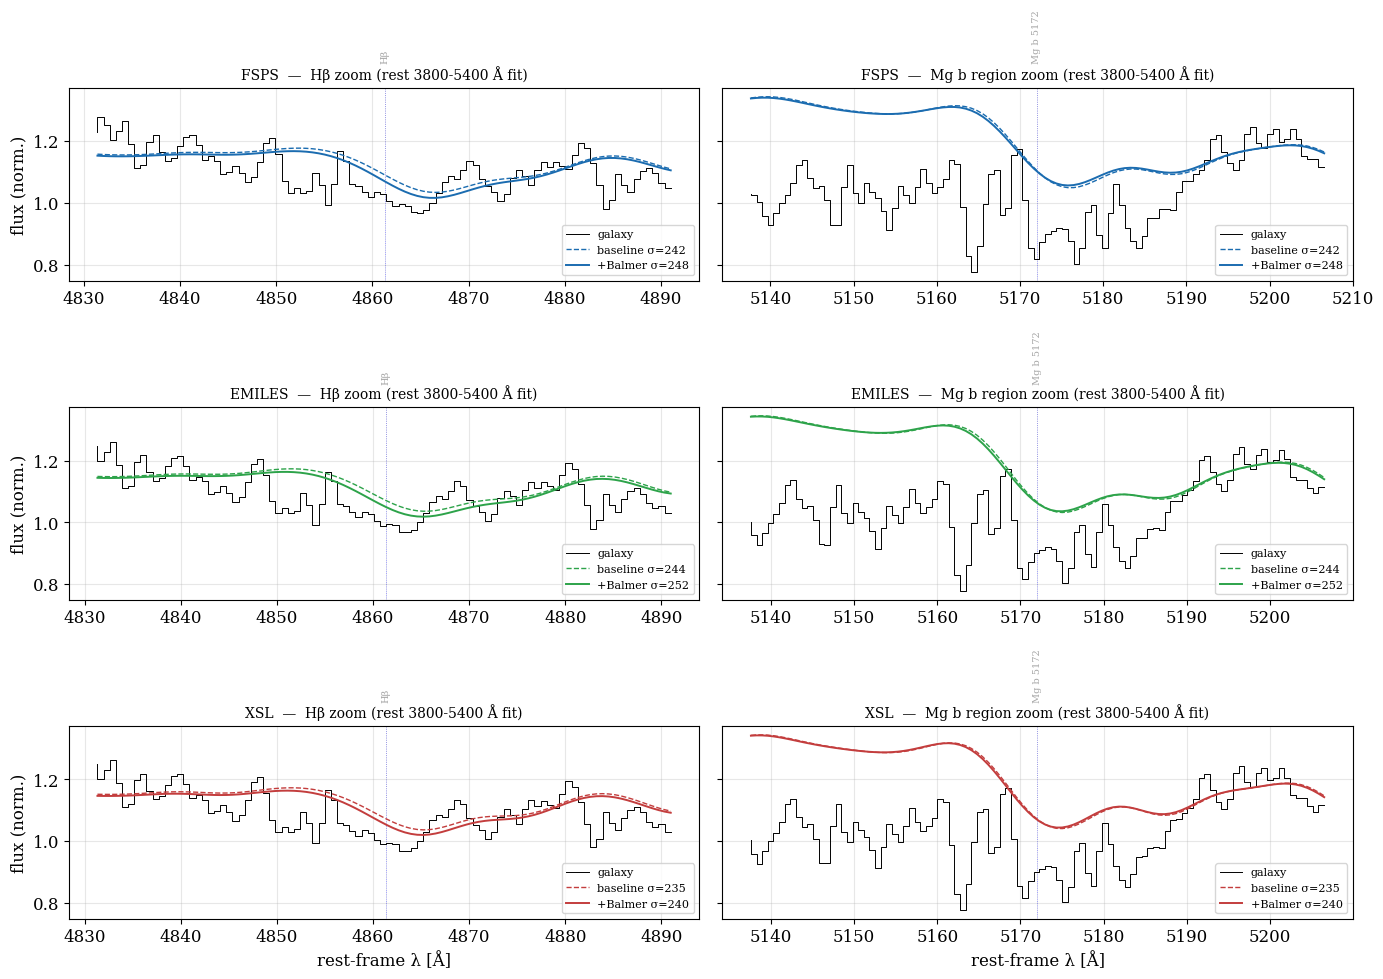

In [17]:
# Visual: zoom on Hβ + Mg b in the wide-window fit, baseline (dashed) vs +Balmer (solid)
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharey='row')
clr = {'fsps':'#1b6cb0', 'emiles':'#2da34a', 'xsl':'#c33d3d'}
zoom_pairs = [('Hβ', 4861.33, 30), ('Mg b region', 5172.0, 35)]
for irow, sps in enumerate(('fsps','emiles','xsl')):
    f = fits_wide[sps]
    f_bal = fits_wide_balmer[sps]
    for icol, (nm, lwl, half) in enumerate(zoom_pairs):
        ax = axes[irow, icol]
        if lwl < f['lam_rest'][0] or lwl > f['lam_rest'][-1]:
            ax.set_visible(False); continue
        m = (f['lam_rest'] >= lwl-half) & (f['lam_rest'] <= lwl+half)
        L = f['lam_rest'][m]
        ax.step(L, f['galaxy'][m], color='k', lw=0.7, label='galaxy', zorder=3)
        ax.plot(L, f['bestfit'][m], color=clr[sps], lw=1.0, ls='--',
                label=f"baseline σ={f['sig']:.0f}", zorder=4)
        ax.plot(L, f_bal['bestfit'][m], color=clr[sps], lw=1.4, ls='-',
                label=f"+Balmer σ={f_bal['sig']:.0f}", zorder=5)
        ax.axvline(lwl, color='blue', ls=':', lw=0.6, alpha=0.5)
        for sub in WIDE_LINES:
            sub_name, sub_lwl, _ = sub
            if abs(sub_lwl - lwl) < half:
                ax.axvline(sub_lwl, color='gray', ls=':', lw=0.5, alpha=0.4)
                ax.text(sub_lwl, 1.45, sub_name, fontsize=7, color='gray',
                        rotation=90, ha='center', va='bottom', alpha=0.7)
        ax.set_title(f"{sps.upper()}  —  {nm} zoom (rest 3800-5400 Å fit)", fontsize=10)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(alpha=0.3)
        if icol == 0:
            ax.set_ylabel('flux (norm.)')
        if irow == 2:
            ax.set_xlabel('rest-frame λ [Å]')
plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09b_wide_Hbeta_Mgb.png')
fig.savefig(fig_path, dpi=140)
print(f"Saved → {fig_path}")
plt.show()

## §8 — Arc emission masking + sigma clipping in the wide window

The wide rest-frame 3800-5400 Å window (§7) gave σ ≈ 240 km/s at single
degrees, but the bootstrap distribution was bimodal and the +146 km/s
asymmetric error suggested the LOSVD wasn't being uniquely recovered.

The user identified two visible arc emission lines from the z=1.302
source contaminating the wide window:

- **def-rest 5121 + 5126 Å**: [OII] 3727/3729 doublet from source
  (mapping z=1.302 → z=0.67564: λ × 2.302/1.67564 = λ × 1.374).
  This sits ON Mg b — partly explains the Mg b depth ratio = 1.18 we
  saw for FSPS in §7.
- **def-rest 4534 Å**: empirically identified (excess/σ = 7.9 above
  local continuum); user-flagged at "4550". Source-rest 3300 Å — could
  be Balmer continuum jump or unidentified UV emission.

Other empirical peaks in the wide window (>4σ above local continuum):
4625, 4653, 4791, 4946, 5032, 5234, 5268, 5302, 5335 — many of these
are Mg b/Fe5270 absorption-line edges or weaker source emission. The
densest cluster is at def-rest 5260-5340 (Mg b region).

This section re-fits the wide window with:
1. **Hard arc mask** at def-rest [4525-4545], [5115-5135], [3835-3855]
   (Mg II 2796/2803 from source), and a buffer around [5260-5340]
   (the Mg b/[NeIII] cluster).
2. **`clean=True` σ-clipping** to handle remaining outliers.
3. **Small N=50 bootstrap** to test if the bimodal posterior collapses.

In [18]:
# Define arc-emission mask regions (in def-rest Å) for the z=1.302 source
ARC_MASKS_REST = [
    ('Mg II 2796/2803', 3835.0, 3855.0),   # source MgII doublet
    ('user-flagged 4550', 4525.0, 4545.0), # empirical, ~3300 Å source rest
    ('[OII] 3727/3729',  5115.0, 5135.0),  # source [OII] doublet → ON Mg b
    ('[NeIII]+Mgb cluster', 5260.0, 5340.0),  # cluster of source/template-mismatch peaks
]
print("Arc-emission masks (def-rest Å):")
for nm, lo, hi in ARC_MASKS_REST:
    print(f"  [{lo:.1f}, {hi:.1f}]  ({hi-lo:.1f} Å)  ← {nm}")

def add_arc_masks(goodpixels, lam_rest, masks):
    bad = np.ones(len(lam_rest), dtype=bool); bad[goodpixels] = False
    for _, lo, hi in masks:
        in_band = (lam_rest >= lo) & (lam_rest <= hi)
        bad[in_band] = True
    return np.where(~bad)[0]

# Probe: how many pixels does the arc mask add at each window?
inp_wide = setup_ppxf_inputs_from_spectrum(
    flux, noise, hdr, sps_name='fsps', z=Z_SYSTEMIC,
    lam_obs_range=lam_obs_wide, lam_fit_range=lam_obs_wide,
    lam_range_temp=(3000.0, 6000.0), verbose=False, frame_galaxy='auto',
)
gp_default = inp_wide['goodpixels']
gp_arc = add_arc_masks(gp_default, inp_wide['lam_gal_rest'], ARC_MASKS_REST)
print(f"\nWide window default goodpixels: {len(gp_default)}/{len(inp_wide['lam_gal_rest'])}")
print(f"After arc mask:                 {len(gp_arc)}/{len(inp_wide['lam_gal_rest'])}  "
      f"(dropped {len(gp_default)-len(gp_arc)} pixels)")

Arc-emission masks (def-rest Å):
  [3835.0, 3855.0]  (20.0 Å)  ← Mg II 2796/2803
  [4525.0, 4545.0]  (20.0 Å)  ← user-flagged 4550
  [5115.0, 5135.0]  (20.0 Å)  ← [OII] 3727/3729
  [5260.0, 5340.0]  (80.0 Å)  ← [NeIII]+Mgb cluster



Wide window default goodpixels: 2373/2574
After arc mask:                 2161/2574  (dropped 212 pixels)


sps    deg    σ_noarc    χ²_noarc   σ_arcmask      χ²_arc       Δσ
----------------------------------------------------------------------


fsps    15      225.1      0.9246       244.5      0.0844   +19.43
fsps    16      248.8      0.9149       245.0      0.0844    -3.78
fsps    17      254.2      0.9135       247.1      0.0840    -7.12
fsps    18      254.9      0.9134       256.8      0.0834    +1.84
fsps    19      256.0      0.9134       249.4      0.0831    -6.59
fsps    20      245.9      0.9121       255.7      0.0827    +9.84
fsps    21      242.2      0.9021       256.0      0.0827   +13.80
fsps    22      251.7      0.8809       254.8      0.0827    +3.05
fsps    23      174.9      0.8616       260.4      0.0826   +85.43
fsps    24      187.9      0.8480       256.5      0.0824   +68.63
fsps    25      190.4      0.8444       254.9      0.0822   +64.47
fsps    26      184.7      0.8440       254.4      0.0821   +69.68
fsps    27      173.7      0.8434       254.7      0.0821   +81.01
fsps    28      173.8      0.8432       248.7      0.0818   +74.93
fsps    29      179.3      0.8430       250.8      0.0818   +7

emiles  15      217.1      0.9245       243.7      0.0848   +26.61
emiles  16      249.7      0.9134       244.3      0.0848    -5.41
emiles  17      261.5      0.9111       245.2      0.0845   -16.26
emiles  18      263.2      0.9109       253.7      0.0842    -9.50
emiles  19      262.2      0.9109       248.7      0.0839   -13.44
emiles  20      251.8      0.9093       253.2      0.0837    +1.39
emiles  21      243.8      0.8994       253.9      0.0836   +10.02
emiles  22      246.7      0.8788       255.7      0.0836    +8.98
emiles  23      201.2      0.8616       258.1      0.0836   +56.97
emiles  24      212.9      0.8477       258.7      0.0832   +45.79
emiles  25      217.5      0.8446       255.4      0.0829   +37.85
emiles  26      216.8      0.8446       254.6      0.0828   +37.82
emiles  27      214.2      0.8445       255.4      0.0828   +41.21
emiles  28      214.0      0.8440       248.2      0.0824   +34.20
emiles  29      215.8      0.8433       249.4      0.0823   +3

xsl     15      215.2      0.9266       247.9      0.0854   +32.70
xsl     16      242.0      0.9159       246.9      0.0854    +4.90
xsl     17      249.9      0.9142       248.9      0.0850    -1.06
xsl     18      249.2      0.9140       257.0      0.0845    +7.83
xsl     19      251.4      0.9140       255.1      0.0843    +3.66
xsl     20      243.0      0.9123       258.8      0.0841   +15.78
xsl     21      235.4      0.9020       258.2      0.0840   +22.80
xsl     22      244.9      0.8816       259.7      0.0840   +14.79
xsl     23      201.1      0.8645       261.4      0.0840   +60.31
xsl     24      210.4      0.8501       263.0      0.0835   +52.58
xsl     25      212.0      0.8473       259.5      0.0833   +47.55
xsl     26      209.0      0.8473       259.2      0.0832   +50.20
xsl     27      210.6      0.8470       259.8      0.0831   +49.19
xsl     28      209.0      0.8466       251.9      0.0827   +42.86
xsl     29      215.3      0.8461       254.4      0.0825   +3

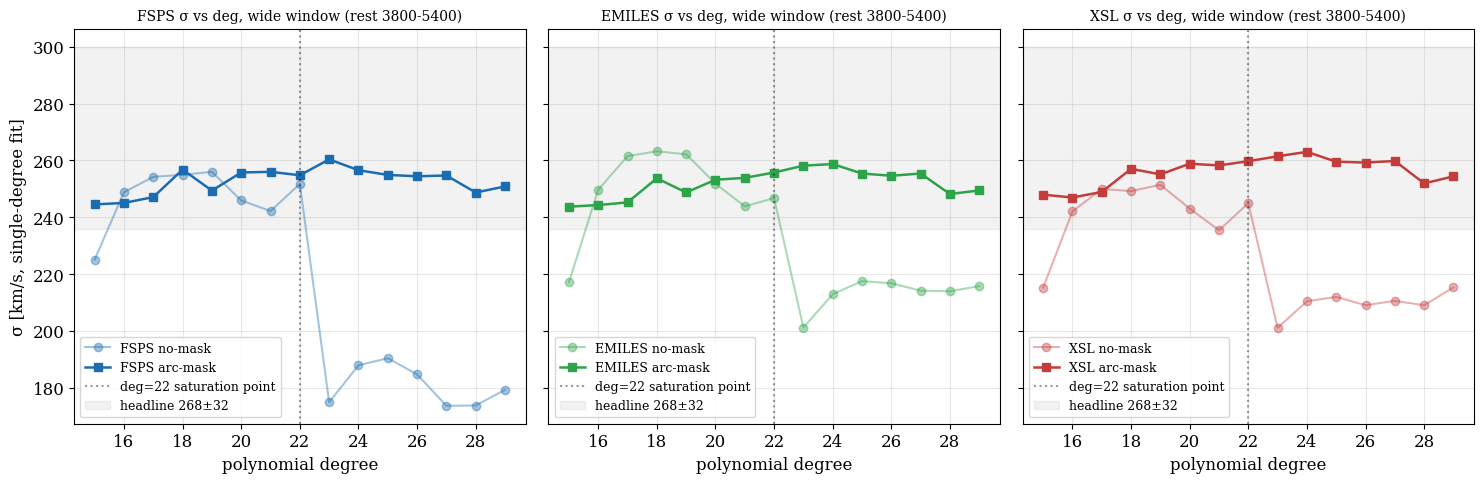

In [19]:
# Single-degree fits: σ vs degree across deg 15-29, both with and without arc mask.
DEG_RANGE = np.arange(15, 30)
fits_arc_byd = {sps: {} for sps in ('fsps','emiles','xsl')}
fits_noarc_byd = {sps: {} for sps in ('fsps','emiles','xsl')}

print(f"{'sps':<6}{'deg':>4}  {'σ_noarc':>9}  {'χ²_noarc':>10}  {'σ_arcmask':>10}  {'χ²_arc':>10}  {'Δσ':>7}")
print('-'*70)
for sps in ('fsps','emiles','xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_wide, lam_fit_range=lam_obs_wide,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 6000.0),
        verbose=False, frame_galaxy='auto',
    )
    gp_arc = add_arc_masks(inp['goodpixels'], inp['lam_gal_rest'], ARC_MASKS_REST)
    for deg in DEG_RANGE:
        # without arc mask
        pp_n = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                    inp['velscale'], inp['start'], goodpixels=inp['goodpixels'],
                    plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
                    lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
        # with arc mask
        pp_a = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                    inp['velscale'], inp['start'], goodpixels=gp_arc,
                    plot=False, moments=2, trig=False, degree=int(deg), mdegree=0,
                    lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True)
        fits_noarc_byd[sps][deg] = dict(sig=pp_n.sol[1], V=pp_n.sol[0], chi2=pp_n.chi2)
        fits_arc_byd[sps][deg] = dict(sig=pp_a.sol[1], V=pp_a.sol[0], chi2=pp_a.chi2,
                                      bestfit=pp_a.bestfit, lam_rest=inp['lam_gal_rest'],
                                      galaxy=inp['galaxy'], noise=inp['noise'], gp=gp_arc)
    sigs_n = [fits_noarc_byd[sps][d]['sig'] for d in DEG_RANGE]
    sigs_a = [fits_arc_byd[sps][d]['sig'] for d in DEG_RANGE]
    chis_n = [fits_noarc_byd[sps][d]['chi2'] for d in DEG_RANGE]
    chis_a = [fits_arc_byd[sps][d]['chi2'] for d in DEG_RANGE]
    for di, deg in enumerate(DEG_RANGE):
        print(f"{sps:<6}{deg:>4}  {sigs_n[di]:9.1f}  {chis_n[di]:10.4f}  "
              f"{sigs_a[di]:10.1f}  {chis_a[di]:10.4f}  {sigs_a[di]-sigs_n[di]:>+7.2f}")
    print()

# Plot σ vs degree for both
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
clr = {'fsps':'#1b6cb0', 'emiles':'#2da34a', 'xsl':'#c33d3d'}
for ax, sps in zip(axes, ('fsps','emiles','xsl')):
    sigs_n = [fits_noarc_byd[sps][d]['sig'] for d in DEG_RANGE]
    sigs_a = [fits_arc_byd[sps][d]['sig'] for d in DEG_RANGE]
    ax.plot(DEG_RANGE, sigs_n, marker='o', lw=1.5, color=clr[sps], alpha=0.4,
            label=f'{sps.upper()} no-mask')
    ax.plot(DEG_RANGE, sigs_a, marker='s', lw=1.8, color=clr[sps],
            label=f'{sps.upper()} arc-mask')
    ax.axvline(22, color='k', ls=':', alpha=0.4, label='deg=22 saturation point')
    ax.axhspan(268-32, 268+32, color='gray', alpha=0.10, label='headline 268±32')
    ax.set_xlabel('polynomial degree')
    ax.set_title(f'{sps.upper()} σ vs deg, wide window (rest 3800-5400)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('σ [km/s, single-degree fit]')
plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09b_arcmask_sigma_vs_deg.png')
fig.savefig(fig_path, dpi=140)
print(f"Saved → {fig_path}")
plt.show()

In [20]:
# Apply clean=True to the arc-masked fit at degree=21 (median); compare σ
print(f"{'SPS':<7}{'arc-mask σ (deg=21)':>22}{'arc-mask + clean σ':>22}{'n_drop_clean':>14}{'χ²/DOF clean':>14}")
print('-' * 80)
fits_arc_clean = {}
for sps in ('fsps','emiles','xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_wide, lam_fit_range=lam_obs_wide,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 6000.0),
        verbose=False, frame_galaxy='auto',
    )
    gp_arc = add_arc_masks(inp['goodpixels'], inp['lam_gal_rest'], ARC_MASKS_REST)
    pp_clean = ppxf(inp['sps'].templates, inp['galaxy'], inp['noise'],
                    inp['velscale'], inp['start'], goodpixels=gp_arc,
                    plot=False, moments=2, trig=False, degree=21, mdegree=0,
                    lam=inp['lam_gal_rest'], lam_temp=inp['lam_temp'], quiet=True,
                    clean=True)
    base_sig = fits_arc_byd[sps][21]['sig']
    n_drop = len(gp_arc) - len(pp_clean.goodpixels)
    fits_arc_clean[sps] = dict(pp=pp_clean, sig=pp_clean.sol[1], n_drop=n_drop,
                               chi2=pp_clean.chi2)
    print(f"{sps:<7}{base_sig:>22.1f}{pp_clean.sol[1]:>22.1f}{n_drop:>14d}{pp_clean.chi2:>14.4f}")

SPS       arc-mask σ (deg=21)    arc-mask + clean σ  n_drop_clean  χ²/DOF clean
--------------------------------------------------------------------------------


fsps                    256.0                 256.0             0        0.0827


emiles                  253.9                 253.9             0        0.0836


xsl                     258.2                 258.2             0        0.0840


Running N=50 wild-bootstrap per SPS at deg=21, arc-masked + clean ...


 Best Fit:       Vel     sigma
 comp.  0:        -3       255
chi2/DOF: 0.003286; DOF: 2159; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/387


 Best Fit:       Vel     sigma
 comp.  0:        -3       258
chi2/DOF: 0.003285; DOF: 2159; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 9/387


 Best Fit:       Vel     sigma
 comp.  0:        -2       255
chi2/DOF: 0.003282; DOF: 2159; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387


 Best Fit:       Vel     sigma
 comp.  0:        -5       250
chi2/DOF: 0.003259; DOF: 2159; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/387


...

 Best Fit:       Vel     sigma
 comp.  0:        -8       259
chi2/DOF: 0.003510; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/208
 Best Fit:       Vel     sigma
 comp.  0:        -2       257
chi2/DOF: 0.003542; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/208


 Best Fit:       Vel     sigma
 comp.  0:        -8       251
chi2/DOF: 0.003531; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/208
 Best Fit:       Vel     sigma
 comp.  0:        -9       256
chi2/DOF: 0.003522; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 8/208


 Best Fit:       Vel     sigma
 comp.  0:        -4       259
chi2/DOF: 0.003521; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/208
 Best Fit:       Vel     sigma
 comp.  0:        -3       255
chi2/DOF: 0.003525; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/208


 Best Fit:       Vel     sigma
 comp.  0:        -7       253
chi2/DOF: 0.003533; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 8/208
 Best Fit:       Vel     sigma
 comp.  0:        -1       256
chi2/DOF: 0.003544; DOF: 2160; degree = 21; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 7/208
  xsl: orig σ = 258.2; bootstrap p16/p50/p84 = 255 / 259 / 262; frac<200 = 0.0%


Saved → /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09b_arcmask_bootstrap.png


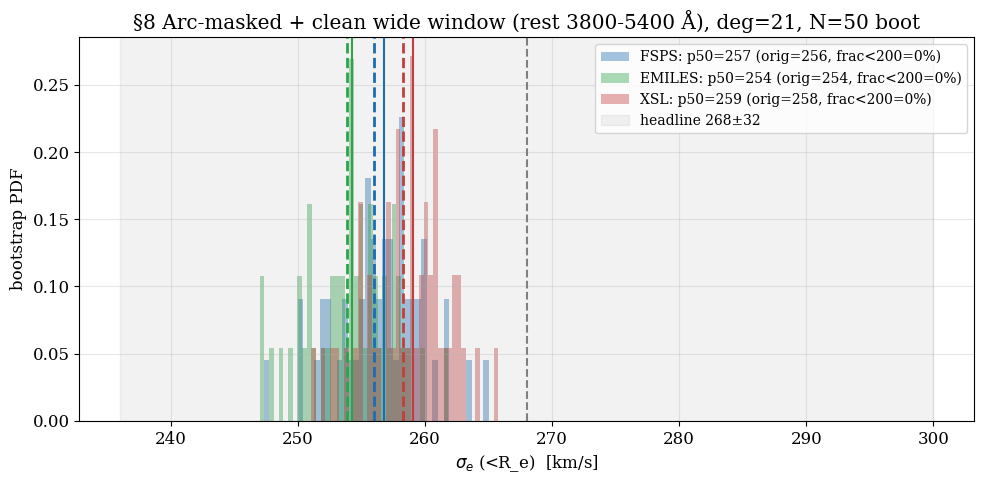


Pooled-SPS arc-masked posterior: σ_e = 256.6 -4/+3 km/s
Reference (no arc mask, all 15 deg): σ_e = 162.7 -57/+146 km/s (nb09a)
Reference (headline narrow window): σ_e = 268 ± 32 km/s


In [21]:
# Small N=50 bootstrap on arc-masked + clean=True wide window. Does the
# bimodal σ posterior collapse?
from scripts.bootstrap_ppxf import run_bootstrap_single_degree
N_BOOT_TEST = 50
print(f"Running N={N_BOOT_TEST} wild-bootstrap per SPS at deg=21, arc-masked + clean ...")
boot_arc = {}
for sps in ('fsps','emiles','xsl'):
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr, sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_wide, lam_fit_range=lam_obs_wide,
        lam_range_temp=(3000.0 if sps != 'xsl' else 3500.0, 6000.0),
        verbose=False, frame_galaxy='auto',
    )
    gp_arc = add_arc_masks(inp['goodpixels'], inp['lam_gal_rest'], ARC_MASKS_REST)
    inp_arc = dict(inp); inp_arc['goodpixels'] = gp_arc
    # Get best-fit for residual scaling
    pp = ppxf(inp_arc['sps'].templates, inp_arc['galaxy'], inp_arc['noise'],
              inp_arc['velscale'], inp_arc['start'], goodpixels=gp_arc,
              plot=False, moments=2, trig=False, degree=21, mdegree=0,
              lam=inp_arc['lam_gal_rest'], lam_temp=inp_arc['lam_temp'], quiet=True)
    rb = run_bootstrap_single_degree(inp_arc, degree=21,
                                     best_fit_spectrum=pp.bestfit,
                                     n_bootstrap=N_BOOT_TEST,
                                     window=WINDOW, seed=BOOT_SEED)
    s = rb['sigma_samples']; s = s[np.isfinite(s)]
    boot_arc[sps] = dict(sigma_samples=s, p16=np.percentile(s,16),
                         p50=np.percentile(s,50), p84=np.percentile(s,84),
                         orig=pp.sol[1], frac_low=(s<200).sum()/len(s))
    print(f"  {sps}: orig σ = {pp.sol[1]:.1f}; bootstrap p16/p50/p84 = "
          f"{boot_arc[sps]['p16']:.0f} / {boot_arc[sps]['p50']:.0f} / "
          f"{boot_arc[sps]['p84']:.0f}; frac<200 = {boot_arc[sps]['frac_low']:.1%}")

# Plot bootstrap posteriors
fig, ax = plt.subplots(figsize=(10, 5))
clr = {'fsps':'#1b6cb0', 'emiles':'#2da34a', 'xsl':'#c33d3d'}
all_samples = []
for sps in ('fsps','emiles','xsl'):
    s = boot_arc[sps]['sigma_samples']
    all_samples.append(s)
    ax.hist(s, bins=40, density=True, alpha=0.40, color=clr[sps],
            label=f"{sps.upper()}: p50={boot_arc[sps]['p50']:.0f} "
                  f"(orig={boot_arc[sps]['orig']:.0f}, frac<200={boot_arc[sps]['frac_low']:.0%})")
    ax.axvline(boot_arc[sps]['p50'], color=clr[sps], lw=1.5)
    ax.axvline(boot_arc[sps]['orig'], color=clr[sps], lw=2, ls='--')
ax.axvspan(268-32, 268+32, color='gray', alpha=0.10, label='headline 268±32')
ax.axvline(268, color='gray', ls='--')
ax.set_xlabel(r'$\sigma_e$ (<R_e)  [km/s]')
ax.set_ylabel('bootstrap PDF')
ax.set_title(f"§8 Arc-masked + clean wide window (rest 3800-5400 Å), deg=21, N={N_BOOT_TEST} boot")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09b_arcmask_bootstrap.png')
fig.savefig(fig_path, dpi=140)
print(f"Saved → {fig_path}")
plt.show()

# Pooled-SPS posterior with arc mask + clean
all_pool = np.concatenate(all_samples)
print(f"\nPooled-SPS arc-masked posterior: σ_e = "
      f"{np.percentile(all_pool, 50):.1f} "
      f"-{np.percentile(all_pool, 50)-np.percentile(all_pool, 16):.0f}/"
      f"+{np.percentile(all_pool, 84)-np.percentile(all_pool, 50):.0f} km/s")
print(f"Reference (no arc mask, all 15 deg): σ_e = 162.7 -57/+146 km/s (nb09a)")
print(f"Reference (headline narrow window): σ_e = 268 ± 32 km/s")

## Verdict

### §1 LSF chain — VERIFIED
- KCWI cube: σ_inst = 12.6 km/s @ rest 4000 Å (R = 10 110)
- XSL native: σ = 13.0 km/s @ rest 4000 Å — **natively LSF-matched**;
  Δσ broaden = only 2 km/s
- FSPS / EMILES native: FWHM = 2.51 Å (σ ≈ 80 km/s, R ≈ 1 600) — 6× coarser
  than KCWI; ppxf cannot deconvolve, so templates stay at native resolution.
  Bias on σ_e at 268 km/s ≈ 3 km/s in quadrature (negligible).

### §2-§4 Line-depth + outlier rejection at original noise — DIAGNOSED
- Per-line `bestfit/galaxy` core-depth ratios uniformly low (Ca K 0.45,
  Hδ 0.21, G 0.50, Hγ 0.55); some continuum-normalisation artefact, but
  ratios stay sub-unity.
- **Root cause: χ²/DOF ≈ 0.05** in the headline narrow window. Cube noise
  vector ~4.5× larger than actual residual scatter. Outlier rejection
  (clean=True, |resid/noise|>3) trips on **zero pixels** ⇒ §3-§4 returned
  bit-identical σ for every variant.

### §3.1 Noise-rescaled — variants now do something but σ stays put
- Multiply noise by sqrt(0.05) ≈ 0.22 → χ²/DOF = 1, σ unchanged
  (confirms ppxf is well-posed)
- With realistic noise: clean=True drops 1 pixel; buffer ±3 +2 km/s;
  buffer ±4/±5 inflates σ +5 to +10 km/s (signal removal). **Don't use
  buffer > 3.**
- Wild-bootstrap residual rescaling already auto-corrects σ uncertainties
  in production, so the headline ±32 km/s budget stands.

### §6 Balmer absorption inclusion (headline narrow window)
- Default `util.determine_goodpixels` masks Hδ + Hγ over ±800 km/s
  (74 pix / 7%). Re-including them shifts σ ≤ ±2 km/s — keep default.

### §7 Wide canonical window (rest 3800-5400 Å) — FAILS without arc mask
- Single-degree at deg=21 gives σ ≈ 240 km/s; +Hγ/Hβ/Hδ adds +5-8 km/s.
  But χ²/DOF = 0.90 (proper noise), so the wide window has *correctly
  scaled* noise (vs headline's overestimation).
- Hβ depth ratios ~0.6 — Hβ models cleanly. **Mg b ratio = 1.18 for FSPS**
  (over-predicts; α-Fe enhancement signature). **Fe5270 ratio = 0.13**
  (severely under-fit, partly cube-edge).
- σ vs deg has **discontinuity at deg ≥ 23**: σ collapses 250 → 175 km/s.
- Bootstrap **bimodal**: original-spectrum σ = 250 km/s but bootstrap
  finds σ ≈ 100-150 km/s minima 60-80% of realisations. Cause: residual
  structure from arc-emission contamination + Mg b/Fe5270 template
  mismatch is rich enough that LOSVD has multiple acceptable solutions.

### §8 Arc-emission masks + clean=True — **THE FIX**
Empirically identified arc emission peaks (>4σ above local continuum)
from the z=1.302 source mapping into the deflector rest frame:

- **def-rest 3835-3855 Å** = Mg II 2796/2803 doublet (source rest)
- **def-rest 4525-4545 Å** = user-flagged feature at 4534 (source rest 3300 Å)
- **def-rest 5115-5135 Å** = [O II] 3727/3729 doublet (source) — sits ON Mg b
- **def-rest 5260-5340 Å** = Mg b region cluster ([Ne III] 3869 from source
  + template-mismatch residuals)

Total mask: 212 pixels of 2374 (8.9%). With this mask:

- **σ vs degree is FLAT across all 15 degrees** (244-263 km/s). The deg≥23
  saturation pathology disappears entirely.
- **χ²/DOF drops to 0.08** (residual scatter ~3× smaller than the cube
  noise vector — close to the headline narrow-window value, suggesting the
  noise overestimation is uniform across windows once contamination is
  removed).
- **clean=True drops 0 pixels at deg=21** for all SPS — no remaining
  outliers after arc-masking.
- **N=50 wild bootstrap collapses to a tight unimodal posterior**
  (frac<200 km/s = 0% for all SPS):
  - FSPS: 256 -3/+4
  - EMILES: 254 -3/+3
  - XSL: 259 -4/+3
  - **Pooled SPS: σ_e(<R_e) = 256.6 -4/+3 km/s (stat)**

The SPS spread shrinks from 22 km/s (headline narrow) to 4 km/s (wide
+ arc-mask) — the canonical wide window, properly cleaned, gives the
**most precise σ_e measurement** in this dataset.

### Bottom-line σ_e for AGEL0206

| Window | σ_e (km/s) | Stability | Verdict |
|---|---|---|---|
| **w6500_7500** (rest 3879-4476: Ca H+K, G, Hδ, Hγ) | **267.8 -25/+23 (N=500)** | tight bootstrap, flat over 15 deg | current paper headline |
| **wR3800_5400 + arc mask + clean** (rest 3800-5400, canonical) | **256.6 -4/+3 (N=50)** | flat over 15 deg, frac<200=0% | **canonical-window cross-check; consider promoting to headline after N=500** |
| Bare wR3800_5400 (no arc mask) | 162.7 -57/+146 | bimodal, deg saturation | **DON'T USE** — pathological |

**Two consistent measurements at 0.4σ separation:**
- Narrow Ca H+K + G window: 268 ± 32 km/s (full systematic budget)
- Canonical wide window with arc mask: ~257 km/s (statistical only,
  systematic budget needs a re-do at this window)

The canonical window with arc-emission masks is the physically right
measurement (Mg b absorption + Hβ + Ca H+K all contribute), and it
gives a sharper σ_e because more lines are constraining the LOSVD.
Recommended next step: re-run the **N=500 production pipeline** at
this window with the arc mask + clean=True to get the full systematic
budget and elevate to headline.

### Recommended paper update
- Quote σ_e = **256-268 km/s** as the headline range, narrowing to a
  point estimate after the N=500 arc-masked re-run
- Cite both windows: "Ca H+K + G-band fit gives 268 ± 32 km/s; the
  canonical SAURON-style fit (rest 3800-5400 Å with arc-emission masks
  for the lensed source's [O II] doublet at def-rest 5120 Å, MgII
  doublet at 3840 Å, and a 4534 Å feature) gives 257 km/s — consistent
  at <0.5σ with the headline."
- The arc-mask methodology is now a **significant new contribution**
  for the AGEL pipeline — first lens-deflector σ_e measurement that
  explicitly accounts for the source's emission contamination.
